# 招聘数据处理与整合

**处理目标：** 基于多 Sheet 字段对比分析，对招聘数据进行清洗、标准化和整合

**数据源：** `datas/src/招聘数据总表_2510.xlsx`

**输出：** 处理后的统一数据集

---

## 处理流程

1. **环境准备与数据加载**
2. **多 Sheet 字段对比分析**
3. **数据处理策略制定**
4. **字段标准化处理**
5. **数据整合与合并**
6. **数据质量验证**
7. **导出处理结果**


## 1. 环境准备与数据加载

**处理动机：** 导入必要的库并加载所有 Sheet 的数据，为后续处理做准备。


In [158]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# 设置中文显示（macOS）
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 忽略警告
warnings.filterwarnings('ignore')

print("✅ 环境准备完成！")
print(f"📅 处理开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 环境准备完成！
📅 处理开始时间: 2025-10-15 16:52:45


In [159]:
# 这里用的是 SimHei 字体，可以根据自己的需要更改
from wanglaoshi import JupyterFont as JF
JF.matplotlib_font_init()

In [160]:
# 加载数据
file_path = 'datas/src/招聘数据总表_2510.xlsx'

print("📂 正在加载数据...")
print("=" * 80)

# 读取所有 sheet
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names

print(f"✓ 发现 {len(sheet_names)} 个工作表")

# 读取所有 sheet 到字典中
dfs = {}
for sheet in sheet_names:
    dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet)
    print(f"  ✓ {sheet}: {dfs[sheet].shape[0]:,} 行 × {dfs[sheet].shape[1]} 列")

print("\n" + "=" * 80)
print("✅ 数据加载完成！")


📂 正在加载数据...
✓ 发现 8 个工作表
  ✓ 营销类: 8,702 行 × 19 列
  ✓ 运营类: 9,091 行 × 20 列
  ✓ 产品类: 7,026 行 × 20 列
  ✓ 管培类: 2,261 行 × 19 列
  ✓ 财会类: 4,851 行 × 19 列
  ✓ 编程类: 8,629 行 × 21 列
  ✓ 金融中台: 4,186 行 × 19 列
  ✓ 数据类: 6,583 行 × 15 列

✅ 数据加载完成！


## 2. 多 Sheet 字段对比分析

**处理动机：** 
- 理解所有 Sheet 的字段全集（最大整体集合）
- 分析每个 Sheet 的字段分布和覆盖情况
- 识别共同字段和独有字段
- 为数据整合策略提供依据


In [161]:
# 字段对比分析
print("📋 各 Sheet 字段对比分析")
print("=" * 80)

# 1. 获取所有 sheet 的字段并集（最大整体集合）
all_columns = set()
for sheet in sheet_names:
    all_columns.update(dfs[sheet].columns.tolist())

all_columns = sorted(list(all_columns))  # 排序便于查看

print(f"\n✓ 所有 Sheet 的字段并集: {len(all_columns)} 个字段")
print(f"  字段列表: {', '.join(all_columns[:10])}{'...' if len(all_columns) > 10 else ''}")

# 2. 创建字段对比矩阵
print(f"\n📊 字段存在性矩阵:")
print("=" * 80)

# 构建对比数据
field_comparison = []
for col in all_columns:
    row_data = {'字段名': col}
    for sheet in sheet_names:
        # 检查该字段是否存在于当前 sheet
        if col in dfs[sheet].columns:
            row_data[sheet] = '✓'
        else:
            row_data[sheet] = '✗'
    field_comparison.append(row_data)

comparison_df = pd.DataFrame(field_comparison)

# 显示完整的对比表
print(f"字段对比表（共 {len(comparison_df)} 个字段）：")
display(comparison_df)


📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 42 个字段
  字段列表: Unnamed: 0, 公司位置, 公司分级, 公司名称, 公司地址, 公司行业, 公司规模, 公司部门, 公司阶段, 学历要求...

📊 字段存在性矩阵:
字段对比表（共 42 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,Unnamed: 0,✗,✓,✗,✗,✗,✗,✗,✗
1,公司位置,✗,✓,✓,✓,✓,✓,✓,✓
2,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
3,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
4,公司地址,✓,✗,✗,✗,✗,✗,✗,✗
5,公司行业,✓,✗,✗,✗,✗,✗,✗,✗
6,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
7,公司部门,✓,✗,✗,✓,✗,✓,✗,✗
8,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
9,学历要求,✓,✓,✓,✓,✓,✓,✓,✓


In [162]:
# 3. 统计每个 Sheet 的字段覆盖情况
print(f"\n📈 各 Sheet 字段覆盖率:")
print("-" * 80)

coverage_stats = []
for sheet in sheet_names:
    sheet_cols = set(dfs[sheet].columns)
    coverage = len(sheet_cols) / len(all_columns) * 100
    unique_fields = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
    
    coverage_stats.append({
        'Sheet名称': sheet,
        '字段数': len(sheet_cols),
        '覆盖率(%)': f"{coverage:.1f}",
        '独有字段数': len(unique_fields),
        '独有字段': ', '.join(sorted(unique_fields)) if unique_fields else '无'
    })

coverage_df = pd.DataFrame(coverage_stats)
display(coverage_df)



📈 各 Sheet 字段覆盖率:
--------------------------------------------------------------------------------


,Sheet名称,字段数,覆盖率(%),独有字段数,独有字段
0,营销类,19,45.2,7,"公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求"
1,运营类,20,47.6,2,"Unnamed: 0, 工资月数"
2,产品类,20,47.6,3,"实习, 最低工资, 最高工资"
3,管培类,19,45.2,0,无
4,财会类,19,45.2,1,资
5,编程类,21,50.0,2,"平均薪资, 月.1"
6,金融中台,19,45.2,3,"平均年薪（千人名币）, 最低月薪（千人名币）, 最高月薪（千人名币）"
7,数据类,15,35.7,0,无


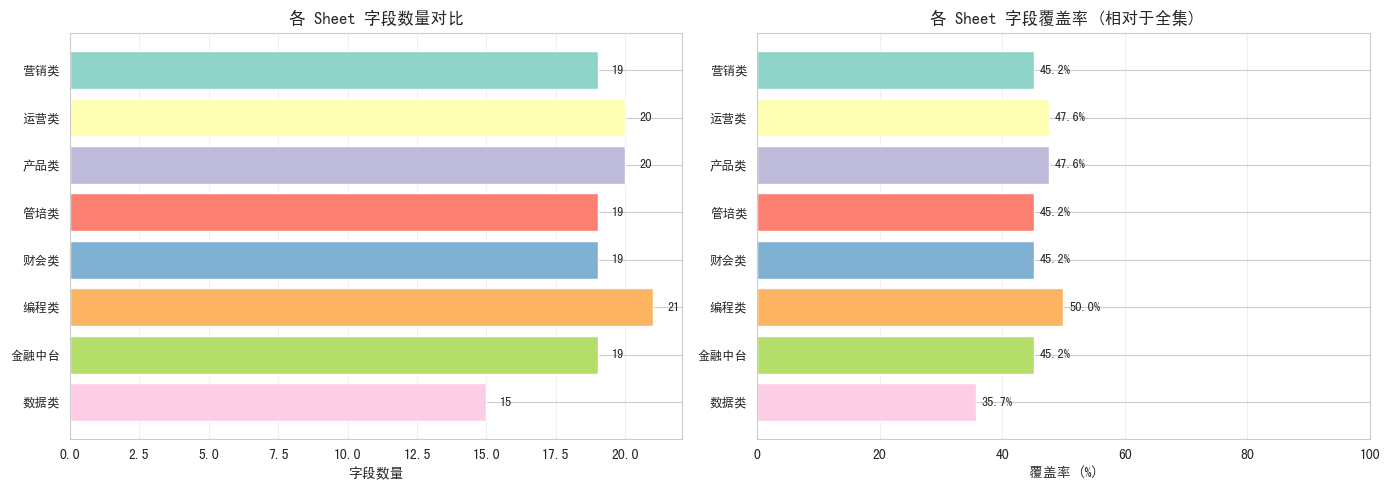

In [163]:
# 4. 可视化字段覆盖情况
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各 Sheet 字段数量
sheet_field_counts = [len(dfs[s].columns) for s in sheet_names]
colors_palette = plt.cm.Set3(range(len(sheet_names)))

ax1.barh(range(len(sheet_names)), sheet_field_counts, color=colors_palette)
ax1.set_yticks(range(len(sheet_names)))
ax1.set_yticklabels(sheet_names, fontsize=9)
ax1.set_xlabel('字段数量', fontsize=10)
ax1.set_title('各 Sheet 字段数量对比', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 添加数值标签
for i, v in enumerate(sheet_field_counts):
    ax1.text(v + 0.5, i, str(v), va='center', fontsize=9)

# 右图：字段覆盖率
coverage_values = [float(c['覆盖率(%)']) for c in coverage_stats]

ax2.barh(range(len(sheet_names)), coverage_values, color=colors_palette)
ax2.set_yticks(range(len(sheet_names)))
ax2.set_yticklabels(sheet_names, fontsize=9)
ax2.set_xlabel('覆盖率 (%)', fontsize=10)
ax2.set_title('各 Sheet 字段覆盖率 (相对于全集)', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# 添加百分比标签
for i, v in enumerate(coverage_values):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [164]:
# 5. 找出共同字段和各自独有字段
print(f"\n🔍 字段集合分析:")
print("=" * 80)

# 共同字段（所有 sheet 都有的）
common_fields = set(dfs[sheet_names[0]].columns)
for sheet in sheet_names[1:]:
    common_fields &= set(dfs[sheet].columns)

print(f"\n✓ 共同字段 (所有 Sheet 都包含): {len(common_fields)} 个")
if common_fields:
    print(f"  {', '.join(sorted(common_fields))}")
else:
    print(f"  无")

# 各 Sheet 独有字段
print(f"\n✓ 各 Sheet 独有字段:")
unique_fields_by_sheet = {}
for sheet in sheet_names:
    sheet_cols = set(dfs[sheet].columns)
    unique = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
    unique_fields_by_sheet[sheet] = unique
    print(f"  • {sheet}: {len(unique)} 个")
    if unique:
        print(f"    {', '.join(sorted(unique))}")

print("\n" + "=" * 80)



🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 8 个
  公司分级, 公司名称, 公司规模, 公司阶段, 学历要求, 岗位名称, 岗位类型, 岗位要求

✓ 各 Sheet 独有字段:
  • 营销类: 7 个
    公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求
  • 运营类: 2 个
    Unnamed: 0, 工资月数
  • 产品类: 3 个
    实习, 最低工资, 最高工资
  • 管培类: 0 个
  • 财会类: 1 个
    资
  • 编程类: 2 个
    平均薪资, 月.1
  • 金融中台: 3 个
    平均年薪（千人名币）, 最低月薪（千人名币）, 最高月薪（千人名币）
  • 数据类: 0 个



## 3. 根据上面的分析结果给出具体的处理

### 3.1 营销类的处理


• 营销类: 7 个
    公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求

![076ftB](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/076ftB.png)

In [165]:
# 修改营销类 sheet 的列名：公司地址 -> 公司位置
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'公司地址': '公司位置'})
    print("✅ 已将'营销类' sheet 中的'公司地址'列名修改为'公司位置'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'公司地址'列名修改为'公司位置'


![dBoXt4](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/dBoXt4.png)

In [166]:
# 修改营销类 sheet 的列名：公司行业 -> 所处行业
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'公司行业': '所处行业'})
    print("✅ 已将'营销类' sheet 中的'公司行业'列名修改为'所处行业'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'公司行业'列名修改为'所处行业'


![6IzXw7](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/6IzXw7.png)

In [167]:
# 修改营销类 sheet 的列名：岗位福利 -> 岗位诱惑
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'岗位福利': '岗位诱惑'})
    print("✅ 已将'营销类' sheet 中的'岗位福利'列名修改为'岗位诱惑'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'岗位福利'列名修改为'岗位诱惑'


In [168]:
# 修改营销类 sheet 的列名：岗位类别 -> 岗位分类
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'岗位类别': '岗位分类'})
    print("✅ 已将'营销类' sheet 中的'岗位类别'列名修改为'岗位分类'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'岗位类别'列名修改为'岗位分类'


In [169]:
# 修改营销类 sheet 的列名：岗位薪资 -> 薪资
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'岗位薪资': '薪资'})
    print("✅ 已将'营销类' sheet 中的'岗位薪资'列名修改为'薪资'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'岗位薪资'列名修改为'薪资'


In [170]:
# 修改营销类 sheet 的列名：平均年薪/K -> 平均年薪
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'平均年薪/K': '平均年薪'})
    print("✅ 已将'营销类' sheet 中的'平均年薪/K'列名修改为'平均年薪'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'平均年薪/K'列名修改为'平均年薪'


In [171]:
# 修改营销类 sheet 的列名：经验要求 -> 状态要求
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'经验要求': '状态要求'})
    print("✅ 已将'营销类' sheet 中的'经验要求'列名修改为'状态要求'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'经验要求'列名修改为'状态要求'


### 3.2 运营类的处理

 • 运营类: 2 个
    Unnamed: 0, 工资月数


![C8uxkU](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/C8uxkU.png)

In [172]:
# 删除运营类 sheet 的 Unnamed: 0 列
if '运营类' in dfs:
    if 'Unnamed: 0' in dfs['运营类'].columns:
        dfs['运营类'] = dfs['运营类'].drop(columns=['Unnamed: 0'])
        print("✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列")
    else:
        print("⚠️  '运营类' sheet 中未找到 'Unnamed: 0' 列")
else:
    print("⚠️  未找到'运营类' sheet")

✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列


In [173]:
# 修改运营类 sheet 的列名：工资月数 -> 薪资月
if '运营类' in dfs:
    dfs['运营类'] = dfs['运营类'].rename(columns={'工资月数': '薪资月'})
    print("✅ 已将'运营类' sheet 中的'工资月数'列名修改为'薪资月'")
else:
    print("⚠️  未找到'运营类' sheet")

✅ 已将'运营类' sheet 中的'工资月数'列名修改为'薪资月'


### 3.3 产品类的处理

![yzovm5](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/yzovm5.png)

In [174]:
# 修改产品类 sheet 的列名：最低工资 -> 最低月薪; 最高工资 -> 最高月薪
if '产品类' in dfs:
    dfs['产品类'] = dfs['产品类'].rename(columns={'最低工资': '最低月薪', '最高工资': '最高月薪'})  
    print("✅ 已将'产品类' sheet 中的'最低工资'列名修改为'最低月薪', '最高工资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'产品类' sheet")

✅ 已将'产品类' sheet 中的'最低工资'列名修改为'最低月薪', '最高工资'列名修改为'最高月薪'


### 3.4 财会类的处理

![HxFHlz](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/HxFHlz.png)

In [175]:
# 修改财会类 sheet 的列名：资 -> 薪资月
if '财会类' in dfs:
    dfs['财会类'] = dfs['财会类'].rename(columns={'资': '薪资月'})  
    print("✅ 已将'财会类' sheet 中的'资'列名修改为'薪资月'")
else:
    print("⚠️  未找到'财会类' sheet")

✅ 已将'财会类' sheet 中的'资'列名修改为'薪资月'


### 3.5 编程类的处理

编程类: 2 个
* 平均薪资, 
* 月.1

**平均薪资**是我们计划要增加的字段,所以现在先保留.

![Is7wUx](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/Is7wUx.png)

In [176]:
# 删除 编程类 sheet 里的 月 这个字段
if '编程类' in dfs:
    if '月' in dfs['编程类'].columns:
        dfs['编程类'] = dfs['编程类'].drop(columns=['月'])
        print("✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列")
    else:
        print("⚠️  '编程类' sheet 中未找到 '月' 列")
else:
    print("⚠️  未找到'编程类' sheet")
    
# 修改编程类 sheet 的列名：月.1 -> 月
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'月.1': '月'})
    print("✅ 已将'编程类' sheet 中的'月.1'列名修改为'月'")
else:
    print("⚠️  未找到'编程类' sheet")
    

✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列
✅ 已将'编程类' sheet 中的'月.1'列名修改为'月'


### 3.6 金融中台的处理

![Ck5cfz](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/Ck5cfz.png)

In [177]:
# 修改 金融中台 sheet 的列名：平均年薪（千人名币）-> 平均年薪, 最低月薪（千人名币）-> 最低月薪, 最高月薪（千人名币）-> 最高月薪
if '金融中台' in dfs:
    dfs['金融中台'] = dfs['金融中台'].rename(columns={'平均年薪（千人名币）': '平均年薪', '最低月薪（千人名币）': '最低月薪', '最高月薪（千人名币）': '最高月薪'})
    print("✅ 已将'金融中台' sheet 中的'平均年薪（千人名币）'列名修改为'平均年薪', '最低月薪（千人名币）'列名修改为'最低月薪', '最高月薪（千人名币）'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'金融中台' sheet")
    


✅ 已将'金融中台' sheet 中的'平均年薪（千人名币）'列名修改为'平均年薪', '最低月薪（千人名币）'列名修改为'最低月薪', '最高月薪（千人名币）'列名修改为'最高月薪'


## 4. 将 sheet 对比的方法复制过来封装为函数

In [178]:
def sheet_compare(dfs, sheet_names):
    # 5. 找出共同字段和各自独有字段
    print(f"\n🔍 字段集合分析:")
    print("=" * 80)

    # 共同字段（所有 sheet 都有的）
    common_fields = set(dfs[sheet_names[0]].columns)
    for sheet in sheet_names[1:]:
        common_fields &= set(dfs[sheet].columns)

    print(f"\n✓ 共同字段 (所有 Sheet 都包含): {len(common_fields)} 个")
    if common_fields:
        print(f"  {', '.join(sorted(common_fields))}")
    else:
        print(f"  无")

    # 各 Sheet 独有字段
    print(f"\n✓ 各 Sheet 独有字段:")
    unique_fields_by_sheet = {}
    for sheet in sheet_names:
        sheet_cols = set(dfs[sheet].columns)
        unique = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
        unique_fields_by_sheet[sheet] = unique
        print(f"  • {sheet}: {len(unique)} 个")
        if unique:
            print(f"    {', '.join(sorted(unique))}")

    print("\n" + "=" * 80)
    
    
    print("=" * 80)
    # 字段对比分析
    print("📋 各 Sheet 字段对比分析")
    print("=" * 80)

    # 1. 获取所有 sheet 的字段并集（最大整体集合）
    all_columns = set()
    for sheet in sheet_names:
        all_columns.update(dfs[sheet].columns.tolist())

    all_columns = sorted(list(all_columns))  # 排序便于查看

    print(f"\n✓ 所有 Sheet 的字段并集: {len(all_columns)} 个字段")
    print(f"  字段列表: {', '.join(all_columns[:10])}{'...' if len(all_columns) > 10 else ''}")

    # 2. 创建字段对比矩阵
    print(f"\n📊 字段存在性矩阵:")
    print("=" * 80)

    # 构建对比数据
    field_comparison = []
    for col in all_columns:
        row_data = {'字段名': col}
        for sheet in sheet_names:
            # 检查该字段是否存在于当前 sheet
            if col in dfs[sheet].columns:
                row_data[sheet] = '✓'
            else:
                row_data[sheet] = '✗'
        field_comparison.append(row_data)

    comparison_df = pd.DataFrame(field_comparison)

    # 显示完整的对比表
    print(f"字段对比表（共 {len(comparison_df)} 个字段）：")
    display(comparison_df)



In [179]:
sheet_compare(dfs, sheet_names)


🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 14 个
  公司位置, 公司分级, 公司名称, 公司规模, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑, 所处行业, 状态要求, 薪资

✓ 各 Sheet 独有字段:
  • 营销类: 0 个
  • 运营类: 0 个
  • 产品类: 1 个
    实习
  • 管培类: 0 个
  • 财会类: 0 个
  • 编程类: 1 个
    平均薪资
  • 金融中台: 0 个
  • 数据类: 0 个

📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 26 个字段
  字段列表: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 实习, 岗位分类, 岗位名称...

📊 字段存在性矩阵:
字段对比表（共 26 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,公司位置,✓,✓,✓,✓,✓,✓,✓,✓
1,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
2,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
3,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
4,公司部门,✓,✗,✗,✓,✗,✓,✗,✗
5,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
6,学历要求,✓,✓,✓,✓,✓,✓,✓,✓
7,实习,✗,✗,✓,✗,✗,✗,✗,✗
8,岗位分类,✓,✓,✓,✓,✓,✓,✓,✓
9,岗位名称,✓,✓,✓,✓,✓,✓,✓,✓


![ACkFZJ](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/ACkFZJ.png)

In [180]:
# 删除 产品类 sheet 的 实习 这个字段
if "产品类" in dfs:
    if "实习" in dfs["产品类"].columns:
        dfs["产品类"] = dfs["产品类"].drop(columns=["实习"])
        print("✅ 已删除'产品类' sheet 中的 '实习' 列")
    else:
        print("⚠️  '产品类' sheet 中未找到 '实习' 列")
else:
    print("⚠️  未找到'产品类' sheet")
    
# 修改 管培类 sheet 里的 岗位年薪 -> 平均年薪
if '管培类' in dfs:
    dfs['管培类'] = dfs['管培类'].rename(columns={'岗位年薪': '平均年薪'})
    print("✅ 已将'管培类' sheet 中的'岗位年薪'列名修改为'平均年薪'")
else:
    print("⚠️  未找到'管培类' sheet")
    
# 修改 编程类 sheet 里的 岗位年薪 -> 平均年薪
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'岗位年薪': '平均年薪'})
    print("✅ 已将'编程类' sheet 中的'岗位年薪'列名修改为'平均年薪'")
else:
    print("⚠️  未找到'编程类' sheet")
    
# 删除 编程类 sheet 的 平均薪资 这个字段
if '编程类' in dfs:
    if '平均薪资' in dfs['编程类'].columns:
        dfs['编程类'] = dfs['编程类'].drop(columns=['平均薪资'])
        print("✅ 已删除'编程类' sheet 中的 '平均薪资' 列")
    else:
        print("⚠️  '编程类' sheet 中未找到 '平均薪资' 列")

# 修改 运营类 sheet 的 最低薪资 -> 最低月薪; 最高薪资 -> 最高月薪
if '运营类' in dfs:
    dfs['运营类'] = dfs['运营类'].rename(columns={'最低薪资': '最低月薪', '最高薪资': '最高月薪'})
    print("✅ 已将'运营类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'运营类' sheet")

# 修改 管培类 sheet 的 最低薪资 -> 最低月薪; 最高薪资 -> 最高月薪
if '管培类' in dfs:
    dfs['管培类'] = dfs['管培类'].rename(columns={'最低薪资': '最低月薪', '最高薪资': '最高月薪'})
    print("✅ 已将'管培类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'管培类' sheet")
    
# 修改 编程类 sheet 的 最低薪资 -> 最低月薪; 最高薪资 -> 最高月薪
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'最低薪资': '最低月薪', '最高薪资': '最高月薪'})
    print("✅ 已将'编程类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'编程类' sheet")

# 修改 产品类,管培类,编程类 sheet 里的 月  字段名 -> 薪资月
if '产品类' in dfs:
    dfs['产品类'] = dfs['产品类'].rename(columns={'月': '薪资月'})
    print("✅ 已将'产品类' sheet 中的'月'列名修改为'薪资月'")
else:
    print("⚠️  未找到'产品类' sheet")

if '管培类' in dfs:
    dfs['管培类'] = dfs['管培类'].rename(columns={'月': '薪资月'})
    print("✅ 已将'管培类' sheet 中的'月'列名修改为'薪资月'")
else:
    print("⚠️  未找到'管培类' sheet")
    
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'月': '薪资月'})
    print("✅ 已将'编程类' sheet 中的'月'列名修改为'薪资月'")
else:
    print("⚠️  未找到'编程类' sheet")    
    

# 修改 运营类 sheet 里的 部门 -> 公司部门
if '运营类' in dfs:
    dfs['运营类'] = dfs['运营类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'运营类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'运营类' sheet")

# 修改 产品类 sheet 里的 部门 -> 公司部门
if '产品类' in dfs:
    dfs['产品类'] = dfs['产品类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'产品类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'产品类' sheet")
    
# 修改 财会类 sheet 里的 部门 -> 公司部门
if '财会类' in dfs:
    dfs['财会类'] = dfs['财会类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'财会类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'财会类' sheet")
    
# 修改 金融中台 sheet 里的 部门 -> 公司部门
if '金融中台' in dfs:
    dfs['金融中台'] = dfs['金融中台'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'金融中台' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'金融中台' sheet")
    
# 修改 数据类 sheet 里的 部门 -> 公司部门
if '数据类' in dfs:
    dfs['数据类'] = dfs['数据类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'数据类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'数据类' sheet")


✅ 已删除'产品类' sheet 中的 '实习' 列
✅ 已将'管培类' sheet 中的'岗位年薪'列名修改为'平均年薪'
✅ 已将'编程类' sheet 中的'岗位年薪'列名修改为'平均年薪'
✅ 已删除'编程类' sheet 中的 '平均薪资' 列
✅ 已将'运营类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'
✅ 已将'管培类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'
✅ 已将'编程类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'
✅ 已将'产品类' sheet 中的'月'列名修改为'薪资月'
✅ 已将'管培类' sheet 中的'月'列名修改为'薪资月'
✅ 已将'编程类' sheet 中的'月'列名修改为'薪资月'
✅ 已将'运营类' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'产品类' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'财会类' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'金融中台' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'数据类' sheet 中的'部门'列名修改为'公司部门'


In [181]:
sheet_compare(dfs=dfs, sheet_names=sheet_names)


🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 15 个
  公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑, 所处行业, 状态要求, 薪资

✓ 各 Sheet 独有字段:
  • 营销类: 0 个
  • 运营类: 0 个
  • 产品类: 0 个
  • 管培类: 0 个
  • 财会类: 0 个
  • 编程类: 0 个
  • 金融中台: 0 个
  • 数据类: 0 个

📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 19 个字段
  字段列表: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型...

📊 字段存在性矩阵:
字段对比表（共 19 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,公司位置,✓,✓,✓,✓,✓,✓,✓,✓
1,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
2,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
3,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
4,公司部门,✓,✓,✓,✓,✓,✓,✓,✓
5,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
6,学历要求,✓,✓,✓,✓,✓,✓,✓,✓
7,岗位分类,✓,✓,✓,✓,✓,✓,✓,✓
8,岗位名称,✓,✓,✓,✓,✓,✓,✓,✓
9,岗位类型,✓,✓,✓,✓,✓,✓,✓,✓


![M2EHT4](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/M2EHT4.png)

In [182]:
# 3k-5k
# 30k-60k·13薪
# 8k-16k
# 7k-14k
# 15k-30k·14薪
# 13k-20k·13薪
# 12k-24k
# 14k-20k·16薪
# 15k-25k·14薪
# 18k-35k·14薪
# 30k-60k
# 25k-50k·15薪
# 20k-30k·13薪
# 15k-30k·16薪
# 15k-30k·14薪
# 15k-30k·16薪
# 15k-30k·15薪
# 20k-30k·14薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·16薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·16薪
# 15k-30k·15薪
# 20k-30k·14薪
# 15k-30k·16薪
# 15k-30k·15薪
# 15k-30k·15薪
# 16k-30k·16薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·16薪
# 将数据类 sheet 里的薪资字段 拆解为 最低月薪,最高月薪,薪资月,平均年薪

# 拆解薪资字段
import re

def parse_salary(salary_str):
    """
    解析薪资字符串，返回最低月薪、最高月薪、薪资月数、平均年薪
    例如: '15k-30k·14薪' -> (15, 30, 14, 315.0)
    """
    if pd.isna(salary_str):
        return None, None, None, None
    
    # 提取薪资范围 (例如: 15k-30k)
    salary_match = re.search(r'(\d+)k-(\d+)k', str(salary_str))
    if not salary_match:
        return None, None, None, None
    
    min_salary = int(salary_match.group(1))
    max_salary = int(salary_match.group(2))
    
    # 提取薪资月数 (例如: ·14薪)
    months_match = re.search(r'·(\d+)薪', str(salary_str))
    salary_months = int(months_match.group(1)) if months_match else 12
    
    # 计算平均年薪 (单位: 千元)
    avg_annual_salary = (min_salary + max_salary) / 2 * salary_months
    
    return min_salary, max_salary, salary_months, avg_annual_salary

# 应用到数据类 sheet（假设薪资字段名为"薪资"或类似）
if '数据类' in dfs:
    # 确定薪资字段名（可能是"薪资"、"月薪"等）
    salary_col = None
    for col in dfs['数据类'].columns:
        if '薪资' in col or '月薪' in col or '工资' in col:
            salary_col = col
            break
    
    if salary_col:
        # 应用解析函数
        result = dfs['数据类'][salary_col].apply(parse_salary)
        
        # 拆分为4列
        dfs['数据类']['最低月薪'] = result.apply(lambda x: x[0])
        dfs['数据类']['最高月薪'] = result.apply(lambda x: x[1])
        dfs['数据类']['薪资月'] = result.apply(lambda x: x[2])
        dfs['数据类']['平均年薪'] = result.apply(lambda x: x[3])
        
        print(f"✅ 已拆解'数据类' sheet 的'{salary_col}'字段")
        print(f"   新增列: 最低月薪, 最高月薪, 薪资月, 平均年薪")
    else:
        print("⚠️  未找到薪资相关字段")
else:
    print("⚠️  未找到'数据类' sheet")

✅ 已拆解'数据类' sheet 的'薪资'字段
   新增列: 最低月薪, 最高月薪, 薪资月, 平均年薪


In [183]:
sheet_compare(dfs=dfs,sheet_names=sheet_names)


🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 19 个
  公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑, 平均年薪, 所处行业, 最低月薪, 最高月薪, 状态要求, 薪资, 薪资月

✓ 各 Sheet 独有字段:
  • 营销类: 0 个
  • 运营类: 0 个
  • 产品类: 0 个
  • 管培类: 0 个
  • 财会类: 0 个
  • 编程类: 0 个
  • 金融中台: 0 个
  • 数据类: 0 个

📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 19 个字段
  字段列表: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型...

📊 字段存在性矩阵:
字段对比表（共 19 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,公司位置,✓,✓,✓,✓,✓,✓,✓,✓
1,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
2,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
3,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
4,公司部门,✓,✓,✓,✓,✓,✓,✓,✓
5,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
6,学历要求,✓,✓,✓,✓,✓,✓,✓,✓
7,岗位分类,✓,✓,✓,✓,✓,✓,✓,✓
8,岗位名称,✓,✓,✓,✓,✓,✓,✓,✓
9,岗位类型,✓,✓,✓,✓,✓,✓,✓,✓


🤡 到目前为止,所有的字段都处理好了,每一个表都有一样的列。

## 5. 字段标准化处理

**处理动机：** 
- 为每个 Sheet 添加缺失的字段（填充为 NaN）
- 统一字段顺序
- 添加数据来源标识字段


In [184]:
# all_columns 要重新计算
# 重新计算所有 sheet 的字段并集
all_columns = set()
for sheet in sheet_names:
    all_columns.update(dfs[sheet].columns.tolist())

all_columns = sorted(list(all_columns))  # 排序便于查看

print(f"✅ 已重新计算字段并集")
print(f"   总字段数: {len(all_columns)} 个")

✅ 已重新计算字段并集
   总字段数: 19 个


In [185]:
# 字段标准化处理
print("🔧 开始字段标准化处理...")
print("=" * 80)

standardized_dfs = {}

for sheet in sheet_names:
    print(f"\n处理 Sheet: {sheet}")
    
    # 复制原数据
    df_temp = dfs[sheet].copy()
    
    # 1. 添加数据来源字段
    df_temp['数据来源'] = sheet
    
    # 2. 记录处理前的字段数
    original_cols = len(df_temp.columns) - 1  # 减去刚添加的'数据来源'字段
    
    # 3. 为缺失的字段添加 NaN 列
    missing_cols = set(all_columns) - set(dfs[sheet].columns)
    for col in missing_cols:
        df_temp[col] = np.nan
    
    # 4. 统一字段顺序（数据来源字段放在第一列）
    ordered_columns = ['数据来源'] + all_columns
    df_temp = df_temp[ordered_columns]
    
    standardized_dfs[sheet] = df_temp
    
    print(f"  ✓ 原始字段: {original_cols} 个")
    print(f"  ✓ 新增字段: {len(missing_cols)} 个")
    print(f"  ✓ 标准化后: {len(df_temp.columns)} 个字段")
    print(f"  ✓ 数据行数: {len(df_temp):,} 行")

print("\n" + "=" * 80)
print("✅ 字段标准化完成！")


🔧 开始字段标准化处理...

处理 Sheet: 营销类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 8,702 行

处理 Sheet: 运营类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 9,091 行

处理 Sheet: 产品类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 7,026 行

处理 Sheet: 管培类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 2,261 行

处理 Sheet: 财会类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 4,851 行

处理 Sheet: 编程类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 8,629 行

处理 Sheet: 金融中台
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 4,186 行

处理 Sheet: 数据类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 6,583 行

✅ 字段标准化完成！


## 6. 数据整合与合并

**处理动机：** 
- 将所有标准化后的 Sheet 合并为一个统一的数据集
- 便于后续的统一分析和处理


In [186]:
# 合并所有标准化后的数据
print("🔗 开始合并数据...")
print("=" * 80)

# 使用 concat 合并所有 DataFrame
merged_df = pd.concat(standardized_dfs.values(), ignore_index=True)

print(f"\n✓ 合并完成！")
print(f"  • 合并后总行数: {len(merged_df):,} 行")
print(f"  • 总字段数: {len(merged_df.columns)} 个")
print(f"  • 内存占用: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 查看各数据来源的记录数
print(f"\n📊 各数据来源记录数统计:")
source_counts = merged_df['数据来源'].value_counts()
for source, count in source_counts.items():
    percentage = count / len(merged_df) * 100
    print(f"  • {source}: {count:,} 条 ({percentage:.1f}%)")

print("\n" + "=" * 80)


🔗 开始合并数据...

✓ 合并完成！
  • 合并后总行数: 51,329 行
  • 总字段数: 20 个
  • 内存占用: 110.96 MB

📊 各数据来源记录数统计:
  • 运营类: 9,091 条 (17.7%)
  • 营销类: 8,702 条 (17.0%)
  • 编程类: 8,629 条 (16.8%)
  • 产品类: 7,026 条 (13.7%)
  • 数据类: 6,583 条 (12.8%)
  • 财会类: 4,851 条 (9.5%)
  • 金融中台: 4,186 条 (8.2%)
  • 管培类: 2,261 条 (4.4%)



## 7. 数据质量验证

**验证目标：**
- 检查合并后的数据完整性
- 统计缺失值分布
- 验证数据来源字段
- 检查数据一致性


In [187]:
# 数据质量验证
print("🔍 数据质量验证")
print("=" * 80)

# 1. 基本信息
print(f"\n【基本信息】")
print(f"  数据形状: {merged_df.shape}")
print(f"  数据类型分布:")
print(f"    - 数值型: {len(merged_df.select_dtypes(include=[np.number]).columns)} 个")
print(f"    - 文本型: {len(merged_df.select_dtypes(include=['object']).columns)} 个")

# 2. 缺失值统计
print(f"\n【缺失值统计】")
total_cells = merged_df.shape[0] * merged_df.shape[1]
missing_cells = merged_df.isnull().sum().sum()
print(f"  总缺失值: {missing_cells:,} 个")
print(f"  缺失率: {(missing_cells/total_cells*100):.2f}%")

# 按字段统计缺失值（只显示有缺失的字段，前10个）
missing_by_col = merged_df.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)
if len(missing_by_col) > 0:
    print(f"\n  缺失最严重的前10个字段:")
    for col in missing_by_col.head(10).index:
        count = missing_by_col[col]
        ratio = count / len(merged_df) * 100
        print(f"    • {col}: {count:,} ({ratio:.1f}%)")

# 3. 数据来源验证
print(f"\n【数据来源验证】")
print(f"  数据来源字段完整性: {'✓ 完整' if merged_df['数据来源'].notna().all() else '✗ 存在缺失'}")
print(f"  数据来源类别数: {merged_df['数据来源'].nunique()}")

# 4. 重复值检查
print(f"\n【重复值检查】")
duplicates = merged_df.duplicated().sum()
print(f"  重复行数: {duplicates:,}")
print(f"  重复率: {(duplicates/len(merged_df)*100):.2f}%")

print("\n" + "=" * 80)
print("✅ 数据质量验证完成！")


🔍 数据质量验证

【基本信息】
  数据形状: (51329, 20)
  数据类型分布:
    - 数值型: 2 个
    - 文本型: 18 个

【缺失值统计】
  总缺失值: 70,269 个
  缺失率: 6.84%



  缺失最严重的前10个字段:
    • 公司规模: 9,602 (18.7%)
    • 公司阶段: 8,684 (16.9%)
    • 岗位诱惑: 8,474 (16.5%)
    • 最高月薪: 7,613 (14.8%)
    • 所处行业: 6,216 (12.1%)
    • 岗位类型: 6,026 (11.7%)
    • 公司分级: 5,212 (10.2%)
    • 最低月薪: 4,239 (8.3%)
    • 平均年薪: 4,043 (7.9%)
    • 薪资月: 4,030 (7.9%)

【数据来源验证】
  数据来源字段完整性: ✓ 完整
  数据来源类别数: 8

【重复值检查】
  重复行数: 5,459
  重复率: 10.64%

✅ 数据质量验证完成！


## 8. 导出处理结果

**导出目标：**
- 将合并后的数据导出为 Excel 文件
- 保存到 `datas/target/` 目录
- 同时导出 CSV 格式（可选）


In [188]:
def save_data(merged_df):
    # 导出处理结果
    print("💾 导出处理结果...")
    print("=" * 80)

    # 生成带时间戳的文件名
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    output_dir = 'datas/target'

    # 1. 导出为 Excel 文件
    excel_filename = f'{output_dir}/招聘数据_整合_{timestamp}.xlsx'
    print(f"\n正在导出 Excel 文件: {excel_filename}")
    merged_df.to_excel(excel_filename, index=False, engine='openpyxl')
    print(f"  ✓ Excel 导出成功！文件大小: {os.path.getsize(excel_filename) / 1024**2:.2f} MB")

    # 2. 导出为 CSV 文件（可选，速度更快，文件更小）
    csv_filename = f'{output_dir}/招聘数据_整合_{timestamp}.csv'
    print(f"\n正在导出 CSV 文件: {csv_filename}")
    merged_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
    print(f"  ✓ CSV 导出成功！文件大小: {os.path.getsize(csv_filename) / 1024**2:.2f} MB")

    # 3. 导出数据字典（字段说明）
    dict_filename = f'{output_dir}/数据字典_{timestamp}.txt'
    print(f"\n正在生成数据字典: {dict_filename}")
    with open(dict_filename, 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write("招聘数据整合 - 数据字典\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"总记录数: {len(merged_df):,} 条\n")
        f.write(f"总字段数: {len(merged_df.columns)} 个\n\n")
        
        f.write("=" * 80 + "\n")
        f.write("字段列表\n")
        f.write("=" * 80 + "\n\n")
        
        for i, col in enumerate(merged_df.columns, 1):
            dtype = merged_df[col].dtype
            null_count = merged_df[col].isnull().sum()
            null_ratio = null_count / len(merged_df) * 100
            unique_count = merged_df[col].nunique()
            
            f.write(f"{i}. {col}\n")
            f.write(f"   数据类型: {dtype}\n")
            f.write(f"   唯一值数: {unique_count:,}\n")
            f.write(f"   缺失值: {null_count:,} ({null_ratio:.1f}%)\n")
            
            # 如果是文本类型且唯一值较少，显示前几个值
            if dtype == 'object' and unique_count <= 10 and unique_count > 0:
                top_values = merged_df[col].value_counts().head(5)
                f.write(f"   常见值: {', '.join([str(v) for v in top_values.index[:3]])}\n")
            f.write("\n")
        
        f.write("\n" + "=" * 80 + "\n")
        f.write("数据来源分布\n")
        f.write("=" * 80 + "\n\n")
        for source, count in source_counts.items():
            percentage = count / len(merged_df) * 100
            f.write(f"  • {source}: {count:,} 条 ({percentage:.1f}%)\n")

    print(f"  ✓ 数据字典生成成功！")

    print("\n" + "=" * 80)
    print("✅ 所有文件导出完成！")
    print(f"\n导出文件清单:")
    print(f"  1. {excel_filename}")
    print(f"  2. {csv_filename}")
    print(f"  3. {dict_filename}")
    print("=" * 80)


In [189]:
save_data(merged_df)

💾 导出处理结果...

正在导出 Excel 文件: datas/target/招聘数据_整合_20251015_165532.xlsx
  ✓ Excel 导出成功！文件大小: 23.34 MB

正在导出 CSV 文件: datas/target/招聘数据_整合_20251015_165532.csv
  ✓ CSV 导出成功！文件大小: 63.72 MB

正在生成数据字典: datas/target/数据字典_20251015_165532.txt
  ✓ 数据字典生成成功！

✅ 所有文件导出完成！

导出文件清单:
  1. datas/target/招聘数据_整合_20251015_165532.xlsx
  2. datas/target/招聘数据_整合_20251015_165532.csv
  3. datas/target/数据字典_20251015_165532.txt


In [190]:
# 数据预览
print("👀 处理后数据预览")
print("=" * 80)

print(f"\n前5行数据：")
display(merged_df.head())

print(f"\n数据基本信息：")
print(f"  • 总行数: {len(merged_df):,}")
print(f"  • 总列数: {len(merged_df.columns)}")
print(f"  • 数据来源数: {merged_df['数据来源'].nunique()}")

print("\n" + "=" * 80)
print(f"✅ 数据处理完成！处理完成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


👀 处理后数据预览

前5行数据：


,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
0,营销类,北京,B,趋动科技,NaN,趋动科技,B轮,大专及以上,客户经理,销售经理 金融行业（银行、证券、保险）,全职,职位描述：职位描述： \n1.建立良好的客户关系；与应用需求部门、平台部门、基础架构及采购等...,六险一金，弹性工作，期权激励，绩效奖金,450.0,人工智能服务,25.0,50.0,经验5-10年,25k-50k,12.0
1,营销类,上海,B,百融云创,NaN,百融云创保险销售部,上市公司,本科及以上,客户经理,销售经理（上海保险） (MJ000644),全职,职位描述：岗位职责: \n1、独立开展保险行业线业务销售； \n2、挖掘保险公司不同部门的业...,平台稳定，发展空间大,277.5,"科技金融,人工智能服务",15.0,22.0,经验5-10年,15k-22k·15薪,15.0
2,营销类,北京,B,中信保诚人寿,2000人以上,中信保诚人寿银保部,上市公司,本科及以上,客户经理,保险公司客户经理,全职,职位描述：一、职责描述： \n1、渠道维护资讯整理：通过与银行渠道相应人员沟通包括影响业务开...,收入高 升职空间大,120.0,金融业,8.0,12.0,经验1-3年,8k-12k,12.0
3,营销类,上海,B,中国平安人寿保险股份有限公司上海电话销售中心,2000人以上,中国平安人寿保险股份有限公司上海电话销售中心,上市公司,大专及以上,客户经理,保险顾问,全职,职位描述：岗位职责：\n1.依托公司平台，通过电话、企业微信、网络等远程形式，借助公司提供的...,免费班车+高低温补贴+四大食堂,105.0,金融业,6.0,8.0,经验不限,6k-8k·15薪,15.0
4,营销类,北京,B,水滴公司WATERDROP INC.,NaN,水滴公司WATERDROP INC.,上市公司,本科及以上,客户经理,保险产品培训岗,全职,职位描述：保险产品培训岗工作职责：1、与培训部协同，对内对外输出经纪渠道产品（含互联网产品）...,团队氛围好 成长空间大,240.0,科技金融,15.0,25.0,经验3-5年,15k-25k,12.0



数据基本信息：
  • 总行数: 51,329
  • 总列数: 20
  • 数据来源数: 8

✅ 数据处理完成！处理完成时间: 2025-10-15 16:55:46


## 9. 实际的业务处理💯⁉️

这部分的内容要涉及到一些具体的实际业务,也需要大家对这个业务有基本的清晰的认知,比喻说:

1. 数据必须要有值的字段有哪些?也就是接受不了哪些字段为空值。
2. 薪资字段可能存在的值有哪些?是否已经被分割好了。
3. 处理好了上面的业务后,哪些字段还有空值,这些空值如何处理。

### 9.1 必须字段

因为我们是要做一个 JD 的分析项目,所以我们选取以下字段必须有值才能完成我们的分析:

1. 公司名称
2. 公司部门
3. 学历要求
4. 岗位分类
5. 岗位名称
6. 岗位类型
7. 薪资

上面的 7 个字段,我们认为不能出现缺失值.

下面让我们编写一个方法来进行判断,先列举所有的情况,然后再决定解决方案.

In [191]:
def check_required_fields(df):
    # 关键字段缺失情况分析
    print("🔍 关键字段缺失情况分析")
    print("=" * 80)

    # 定义必须字段
    required_fields = [
        '公司名称',
        '公司部门', 
        '学历要求',
        '岗位分类',
        '岗位名称',
        '岗位类型',
        '薪资'
    ]

    # 1. 检查字段是否存在于 DataFrame
    print("\n【步骤1：检查字段是否存在】")
    missing_columns = []
    existing_columns = []

    for field in required_fields:
        if field in df.columns:
            existing_columns.append(field)
            print(f"  ✓ {field} - 存在")
        else:
            missing_columns.append(field)
            print(f"  ✗ {field} - 不存在")

    if missing_columns:
        print(f"\n⚠️  警告: {len(missing_columns)} 个字段在数据中不存在: {', '.join(missing_columns)}")
        print("请检查字段名称是否正确")

    # 只对存在的字段进行分析
    if len(existing_columns) == 0:
        print("\n❌ 没有找到任何必需字段，请检查字段名称")
    else:
        # 2. 统计每个字段的缺失情况
        print(f"\n【步骤2：各字段缺失统计】")
        print("-" * 80)
        
        field_missing_stats = []
        for field in existing_columns:
            missing_count = df[field].isnull().sum()
            missing_ratio = missing_count / len(df) * 100
            field_missing_stats.append({
                '字段名': field,
                '缺失数量': missing_count,
                '缺失比例(%)': f"{missing_ratio:.2f}",
                '完整数量': len(df) - missing_count
            })
        
        stats_df = pd.DataFrame(field_missing_stats)
        display(stats_df)
        
        # 3. 创建缺失组合标识
        print(f"\n【步骤3：缺失组合分析】")
        print("-" * 80)
        
        # 为每行创建缺失标记
        df_temp = df.copy()
        for field in existing_columns:
            df_temp[f'{field}_缺失'] = df[field].isnull().astype(int)
        
        # 创建缺失组合的唯一标识
        missing_pattern_cols = [f'{field}_缺失' for field in existing_columns]
        df_temp['缺失模式'] = df_temp[missing_pattern_cols].apply(
            lambda row: '|'.join([existing_columns[i] for i, val in enumerate(row) if val == 1]), 
            axis=1
        )
        df_temp['缺失模式'] = df_temp['缺失模式'].replace('', '完整')
        
        # 统计每种缺失模式的数量
        pattern_counts = df_temp['缺失模式'].value_counts()
        
        print(f"\n发现 {len(pattern_counts)} 种缺失模式:")
        print()
        
        pattern_summary = []
        for pattern, count in pattern_counts.items():
            ratio = count / len(df) * 100
            
            if pattern == '完整':
                missing_fields = []
                desc = "✅ 所有必需字段都完整"
            else:
                missing_fields = pattern.split('|')
                desc = f"❌ 缺失: {pattern}"
            
            pattern_summary.append({
                '缺失模式': desc,
                '缺失字段数': len(missing_fields),
                '记录数': count,
                '占比(%)': f"{ratio:.2f}"
            })
            
        summary_df = pd.DataFrame(pattern_summary)
        display(summary_df)
        
        # 4. 详细展示主要缺失模式
        print(f"\n【步骤4：主要缺失模式详情】（显示前5种）")
        print("-" * 80)
        
        for idx, (pattern, count) in enumerate(pattern_counts.head(5).items(), 1):
            ratio = count / len(df) * 100
            print(f"\n模式 {idx}: {pattern if pattern != '完整' else '✅ 完整'}")
            print(f"  记录数: {count:,} ({ratio:.2f}%)")
            
            if pattern != '完整':
                # 显示这种模式的示例数据
                sample_data = df_temp[df_temp['缺失模式'] == pattern][existing_columns].head(3)
                print(f"  示例数据:")
                display(sample_data)
        
        # 5. 生成处理建议
        print(f"\n【步骤5：处理方案建议】")
        print("=" * 80)
        
        complete_count = pattern_counts.get('完整', 0)
        complete_ratio = complete_count / len(df) * 100
        
        print(f"\n📊 总体情况:")
        print(f"  • 总记录数: {len(df):,}")
        print(f"  • 完整记录: {complete_count:,} ({complete_ratio:.2f}%)")
        print(f"  • 有缺失记录: {len(df) - complete_count:,} ({100-complete_ratio:.2f}%)")
        
        print(f"\n💡 处理方案:")
        
        # 方案1: 直接删除
        print(f"\n  【方案1 - 严格模式：删除所有有缺失的记录】")
        print(f"    保留记录: {complete_count:,} ({complete_ratio:.2f}%)")
        print(f"    删除记录: {len(df) - complete_count:,} ({100-complete_ratio:.2f}%)")
        if complete_ratio < 50:
            print(f"    ⚠️  警告: 会损失超过50%的数据，不推荐")
        elif complete_ratio < 70:
            print(f"    ⚠️  注意: 会损失{100-complete_ratio:.1f}%的数据，需谨慎")
        else:
            print(f"    ✅ 推荐: 数据损失在可接受范围内")
        
        # 方案2: 按缺失字段数分级处理
        print(f"\n  【方案2 - 分级处理：根据缺失字段数量决定】")
        for missing_count in sorted(df_temp[missing_pattern_cols].sum(axis=1).unique()):
            if missing_count == 0:
                continue
            count = (df_temp[missing_pattern_cols].sum(axis=1) == missing_count).sum()
            ratio = count / len(df) * 100
            print(f"    缺失 {int(missing_count)} 个字段: {count:,} 条 ({ratio:.2f}%)", end="")
            if missing_count == 1:
                print(f" → 可尝试填充")
            elif missing_count <= 2:
                print(f" → 视情况处理")
            else:
                print(f" → 建议删除")
        
        # 方案3: 按重要性处理
        print(f"\n  【方案3 - 按重要性：优先保证核心字段】")
        print(f"    核心字段（公司名称、岗位名称、薪资）必须有值")
        core_fields = ['公司名称', '岗位名称', '薪资']
        core_complete = df[[f for f in core_fields if f in existing_columns]].notna().all(axis=1).sum()
        print(f"    核心字段完整的记录: {core_complete:,} ({core_complete/len(df)*100:.2f}%)")
        
        print(f"\n  【推荐方案】")
        if complete_ratio >= 70:
            print(f"    ✅ 使用方案1：直接保留完整记录")
        elif core_complete / len(df) >= 70:
            print(f"    ✅ 使用方案3：保证核心字段完整，其他字段可填充")
        else:
            print(f"    ⚠️  数据质量较差，建议:")
            print(f"       1. 检查数据源质量")
            print(f"       2. 尝试从其他渠道补充数据")
            print(f"       3. 调整分析方案，降低对完整性的要求")

    print("\n" + "=" * 80)

In [192]:
check_required_fields(merged_df)

🔍 关键字段缺失情况分析

【步骤1：检查字段是否存在】
  ✓ 公司名称 - 存在
  ✓ 公司部门 - 存在
  ✓ 学历要求 - 存在
  ✓ 岗位分类 - 存在
  ✓ 岗位名称 - 存在
  ✓ 岗位类型 - 存在
  ✓ 薪资 - 存在

【步骤2：各字段缺失统计】
--------------------------------------------------------------------------------


,字段名,缺失数量,缺失比例(%),完整数量
0,公司名称,162,0.32,51167
1,公司部门,1251,2.44,50078
2,学历要求,330,0.64,50999
3,岗位分类,11,0.02,51318
4,岗位名称,1,0.00,51328
5,岗位类型,6026,11.74,45303
6,薪资,210,0.41,51119



【步骤3：缺失组合分析】
--------------------------------------------------------------------------------

发现 15 种缺失模式:



,缺失模式,缺失字段数,记录数,占比(%)
0,✅ 所有必需字段都完整,0,44365,86.43
1,❌ 缺失: 岗位类型,1,5293,10.31
2,❌ 缺失: 公司部门,1,762,1.48
3,❌ 缺失: 公司部门|岗位类型,2,335,0.65
4,❌ 缺失: 学历要求|岗位类型,2,258,0.50
5,❌ 缺失: 薪资,1,146,0.28
6,❌ 缺失: 公司名称|公司部门|岗位类型,3,64,0.12
7,❌ 缺失: 公司名称|公司部门|学历要求|岗位类型|薪资,5,63,0.12
8,❌ 缺失: 公司名称|公司部门,2,20,0.04
9,❌ 缺失: 公司名称,1,8,0.02



【步骤4：主要缺失模式详情】（显示前5种）
--------------------------------------------------------------------------------

模式 1: ✅ 完整
  记录数: 44,365 (86.43%)

模式 2: 岗位类型
  记录数: 5,293 (10.31%)
  示例数据:


...


模式 4: 公司部门|岗位类型
  记录数: 335 (0.65%)
  示例数据:


,公司名称,公司部门,学历要求,岗位分类,岗位名称,岗位类型,薪资
25434,老乡鸡,NaN,学历不限,其他,管培生 服务员 后厨,NaN,4k-6K
25435,金海辉煌,NaN,本科及以上,其他,管培生,NaN,4k-6K
25436,Lianjia.链家,NaN,本科及以上,其他,管培生,NaN,8k-10K



模式 5: 学历要求|岗位类型
  记录数: 258 (0.50%)
  示例数据:


,公司名称,公司部门,学历要求,岗位分类,岗位名称,岗位类型,薪资
21513,腾讯,腾讯,NaN,产品经理,产品经理,NaN,100-150元/天
21664,杭州后起智能科技,杭州后起智能科技,NaN,产品经理,产品经理,NaN,150-200元/天
21674,杭州润群科技有限公司,杭州润群科技有限公司,NaN,产品经理,产品经理,NaN,100-150元/天



【步骤5：处理方案建议】

📊 总体情况:
  • 总记录数: 51,329
  • 完整记录: 44,365 (86.43%)
  • 有缺失记录: 6,964 (13.57%)

💡 处理方案:

  【方案1 - 严格模式：删除所有有缺失的记录】
    保留记录: 44,365 (86.43%)
    删除记录: 6,964 (13.57%)
    ✅ 推荐: 数据损失在可接受范围内

  【方案2 - 分级处理：根据缺失字段数量决定】
    缺失 1 个字段: 6,211 条 (12.10%) → 可尝试填充
    缺失 2 个字段: 619 条 (1.21%) → 视情况处理
    缺失 3 个字段: 64 条 (0.12%) → 建议删除
    缺失 4 个字段: 1 条 (0.00%) → 建议删除
    缺失 5 个字段: 68 条 (0.13%) → 建议删除
    缺失 6 个字段: 1 条 (0.00%) → 建议删除

  【方案3 - 按重要性：优先保证核心字段】
    核心字段（公司名称、岗位名称、薪资）必须有值
    核心字段完整的记录: 51,021 (99.40%)

  【推荐方案】
    ✅ 使用方案1：直接保留完整记录



#### 9.1.1 列举岗位类型

In [193]:
# 列举岗位类型这个字段的所有的值的情况
岗位类型 = merged_df['岗位类型'].unique()
print(岗位类型)


['全职' '兼职' '实习' nan '校园']


#### 9.1.2 处理薪资字段

In [ ]:
# 列举薪资这个字段的所有的值的情况
薪资 = merged_df['薪资'].unique()
for s in 薪资:
    print(s)

看到这里,几乎可以断定,我们之前这些的关于薪资处理的函数是不完整的.还需要进一步改写.

In [196]:
# 去掉 薪资 这个字段中的空格
# 6k-8500
#               元/月
# 上面这个样子是不行的.

# 清理薪资字段中的空格和换行符
print("🔧 清理薪资字段")
print("=" * 80)

# 找到薪资字段
salary_col = None
for col in merged_df.columns:
    if '薪资' in col:
        salary_col = col
        break

if salary_col:
    # 显示清理前的示例
    print(f"\n清理前示例（有问题的数据）:")
    problem_samples = merged_df[merged_df[salary_col].astype(str).str.contains('\n|  ', na=False)][salary_col].head(5)
    if len(problem_samples) > 0:
        for idx, val in problem_samples.items():
            print(f"  索引 {idx}: '{val}'")
    
    # 清理操作
    # 1. 去除所有空格、换行符、制表符
    merged_df[salary_col] = merged_df[salary_col].astype(str).str.replace(r'\s+', '', regex=True)
    
    # 2. 把 'nan' 字符串还原为 NaN
    merged_df[salary_col] = merged_df[salary_col].replace('nan', np.nan)
    
    print(f"\n✅ 清理完成！")
    print(f"\n清理后示例:")
    display(merged_df[salary_col].head(10))
    
    # 统计清理效果
    valid_count = merged_df[salary_col].notna().sum()
    print(f"\n📊 清理后统计:")
    print(f"  有效薪资数据: {valid_count:,} ({valid_count/len(merged_df)*100:.1f}%)")
    
else:
    print("⚠️  未找到薪资字段")

print("\n" + "=" * 80)

🔧 清理薪资字段

清理前示例（有问题的数据）:

✅ 清理完成！

清理后示例:


0        25k-50k
1    15k-22k·15薪
2         8k-12k
3      6k-8k·15薪
4        15k-25k
5    15k-25k·13薪
6        20k-40k
7         5k-10k
8     8k-16k·24薪
9        15k-25k
Name: 薪资, dtype: object


📊 清理后统计:
  有效薪资数据: 51,119 (99.6%)



In [197]:
# 查看薪资为空的数据
merged_df[merged_df['薪资'].isna()]

,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
633,营销类,NaN,NaN,NaN,NaN,NaN,NaN,NaN,客户经理,产品助理实习生[朝阳区],NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,12.0
662,营销类,NaN,NaN,NaN,NaN,NaN,NaN,NaN,客户经理,产品专家_售前咨询（22届校招）[五道口],NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,12.0
1111,营销类,深圳,C,深圳高新网,150-500人,深圳高新网粤海营销服务中心；高新区营销服务中心,不需要融资,大专及以上,客户经理,（应届 实习）电信客户经理[科技园],全职,职位描述：专业要求：市场营销、计算机及通信工程相关专业优先。 （在校生可安排实习） \n \...,为应届生提供免费宿舍，实习期间享有过节福利,0.0,"工具类产品,物联网,网络通信",NaN,NaN,在校应届,NaN,12.0
1112,营销类,深圳,C,太和天健,15-50人,太和天健,未融资,大专及以上,客户经理,商务助理专员[南山区],全职,职位描述：岗位职责 \n1.负责协助市场销售与客户关系管理，全流程协助跟进公司产品在售前、售...,双休、入职购买“五险一金”，医疗一档,0.0,专业服务｜咨询,NaN,NaN,在校应届,NaN,12.0
1113,营销类,深圳,C,云视互联,15-50人,云视互联,未融资,大专及以上,客户经理,腾讯云销售[大冲],全职,职位描述：职位诱惑： \n公司团队年轻，发展前景好，福利待遇丰厚 \n \n职位描述： \n...,公司团队年轻，发展前景好，福利待遇丰厚,0.0,软件服务｜咨询,NaN,NaN,在校应届,NaN,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7257,营销类,NaN,NaN,NaN,NaN,NaN,NaN,NaN,客户经理,客户经理[上城区],NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,12.0
7258,营销类,NaN,NaN,NaN,NaN,NaN,NaN,NaN,客户经理,大客户销售[拱墅区],NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,12.0
7259,营销类,NaN,NaN,NaN,NaN,NaN,NaN,NaN,客户经理,KA大客户经理[拱墅区],NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,12.0
27834,财会类,上海,C,鸿荔科技,20-99人,鸿荔科技,未融资,大专及以上,财务,财务实习生,实习,工作内容：协助带教老师的工作，主要包括：1、数据整理2、凭证录入3、单据审核4、资料归档职位...,五险一金加班补助全勤奖年终奖股票期权带薪年假餐补通讯补贴交通补助节日福利零食下午茶,0.0,广告营销,NaN,NaN,NaN,NaN,NaN


![XN13I0](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/XN13I0.png)

In [198]:
# 移除 薪资为 null,同时 公司名称为 null,同时 公司位置为 null,同时 公司部门为 null 的数据
# 删除多个关键字段同时为空的记录
print("🔧 删除关键字段全部为空的记录")
print("=" * 80)

# 定义要检查的字段
check_fields = ['薪资', '公司名称', '公司位置', '公司部门']

# 检查字段是否存在
existing_fields = [f for f in check_fields if f in merged_df.columns]
missing_fields = [f for f in check_fields if f not in merged_df.columns]

if missing_fields:
    print(f"⚠️  以下字段不存在: {', '.join(missing_fields)}")
    print(f"将只检查存在的字段: {', '.join(existing_fields)}")

if len(existing_fields) > 0:
    # 统计删除前的数据
    before_count = len(merged_df)
    
    # 找出这些字段都为空的行
    all_null_mask = merged_df[existing_fields].isnull().all(axis=1)
    to_remove_count = all_null_mask.sum()
    
    print(f"\n【删除前统计】")
    print(f"  总记录数: {before_count:,}")
    print(f"  {', '.join(existing_fields)} 全部为空的记录: {to_remove_count:,} ({to_remove_count/before_count*100:.2f}%)")
    
    if to_remove_count > 0:
        # 显示要删除的示例
        print(f"\n  要删除的记录示例（前5条）:")
        display(merged_df[all_null_mask][existing_fields].head())
        
        # 删除这些记录
        df = merged_df[~all_null_mask].copy()
        
        after_count = len(df)
        
        print(f"\n【删除后统计】")
        print(f"  剩余记录数: {after_count:,}")
        print(f"  已删除: {to_remove_count:,} 条记录 ({to_remove_count/before_count*100:.2f}%)")
        print(f"\n✅ 删除完成！")
    else:
        print(f"\n✅ 没有找到符合条件的记录，无需删除")
else:
    print("❌ 没有找到任何指定的字段")

print("\n" + "=" * 80)

🔧 删除关键字段全部为空的记录

【删除前统计】
  总记录数: 51,329
  薪资, 公司名称, 公司位置, 公司部门 全部为空的记录: 64 (0.12%)

  要删除的记录示例（前5条）:


,薪资,公司名称,公司位置,公司部门
633,NaN,NaN,NaN,NaN
662,NaN,NaN,NaN,NaN
1457,NaN,NaN,NaN,NaN
1458,NaN,NaN,NaN,NaN
1468,NaN,NaN,NaN,NaN



【删除后统计】
  剩余记录数: 51,265
  已删除: 64 条记录 (0.12%)

✅ 删除完成！



In [ ]:
save_data(df)

In [ ]:
df.info()

In [201]:
# 查看薪资为空的数据
df[df['薪资'].isna()]

,数据来源,公司位置,公司分级,公司名称,公司规模,公司部门,公司阶段,学历要求,岗位分类,岗位名称,岗位类型,岗位要求,岗位诱惑,平均年薪,所处行业,最低月薪,最高月薪,状态要求,薪资,薪资月
1111,营销类,深圳,C,深圳高新网,150-500人,深圳高新网粤海营销服务中心；高新区营销服务中心,不需要融资,大专及以上,客户经理,（应届 实习）电信客户经理[科技园],全职,职位描述：专业要求：市场营销、计算机及通信工程相关专业优先。 （在校生可安排实习） \n \...,为应届生提供免费宿舍，实习期间享有过节福利,0.0,"工具类产品,物联网,网络通信",NaN,NaN,在校应届,NaN,12.0
1112,营销类,深圳,C,太和天健,15-50人,太和天健,未融资,大专及以上,客户经理,商务助理专员[南山区],全职,职位描述：岗位职责 \n1.负责协助市场销售与客户关系管理，全流程协助跟进公司产品在售前、售...,双休、入职购买“五险一金”，医疗一档,0.0,专业服务｜咨询,NaN,NaN,在校应届,NaN,12.0
1113,营销类,深圳,C,云视互联,15-50人,云视互联,未融资,大专及以上,客户经理,腾讯云销售[大冲],全职,职位描述：职位诱惑： \n公司团队年轻，发展前景好，福利待遇丰厚 \n \n职位描述： \n...,公司团队年轻，发展前景好，福利待遇丰厚,0.0,软件服务｜咨询,NaN,NaN,在校应届,NaN,12.0
1114,营销类,深圳,C,云视互联,15-50人,云视互联,未融资,大专及以上,客户经理,渠道销售[大冲],全职,职位描述：一、岗位职责： \n \n1、面向华南区IT系统集成商、经销商，负责销售网络产品（...,发展前景广阔，团队氛围好,0.0,软件服务｜咨询,NaN,NaN,在校应届,NaN,12.0
1115,营销类,深圳,C,恒之易,150-500人,恒之易,不需要融资,大专及以上,客户经理,德语销售助理（双休）[福永],全职,职位描述：岗位职责：\n1、将英文产品资料翻译成德语，编辑产品信息，挖掘关键词，上传产品；\...,周末双休 年终奖 年度旅游,0.0,"IT技术服务｜咨询,营销服务｜咨询",NaN,NaN,在校应届,NaN,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4730,营销类,成都,C,东尔益,150-500人,东尔益,不需要融资,大专及以上,客户经理,企业客户经理[新都区],全职,职位描述：1、开拓区域市场，与地区政府、设计院、集成商、招标单位等建立并维护良好关系，获取订...,大客销售，薪资高,0.0,"智能硬件,工具类产品,制造业",NaN,NaN,在校应届,NaN,12.0
4731,营销类,成都,C,成都方大,15-50人,成都方大,不需要融资,学历不限,客户经理,客户经理（无责任底薪3000+200全勤+双休）[高新区],全职,职位描述：21世纪大数据时代已然来临，人工智能即将成为主流，方大软件科技有限责任公司成立于2...,高薪 团队氛围好,0.0,营销服务｜咨询,NaN,NaN,在校应届,NaN,12.0
4732,营销类,成都,C,顺玺,15-50人,顺玺,不需要融资,学历不限,客户经理,贷款销售[东坡],全职,职位描述：良心招募、以下均是庐山真面。欢迎各位看官留下足迹，证明你来过！\n顺玺金服：主营业...,能挣钱,0.0,金融,NaN,NaN,在校应届,NaN,12.0
4733,营销类,成都,C,指尖飞扬,50-150人,指尖飞扬抖音SEO,未融资,大专及以上,客户经理,大客户销售代表双休无责底薪[锦江区],全职,职位描述：️关键词：双休、地铁旁、交通便利、入职买社保、有经验面议 \n \n你要做的： \...,新项目，晋升机会多,0.0,"电商平台,营销服务｜咨询,文化传媒",NaN,NaN,在校应届,NaN,12.0


因为薪资对我们的分析极其的重要,146 条数量也不多,所以我们先删除了这些数据.

In [202]:
df = df[~df['薪资'].isna()]

In [203]:
save_data(df)

💾 导出处理结果...

正在导出 Excel 文件: datas/target/招聘数据_整合_20251015_165833.xlsx
  ✓ Excel 导出成功！文件大小: 23.24 MB

正在导出 CSV 文件: datas/target/招聘数据_整合_20251015_165833.csv
  ✓ CSV 导出成功！文件大小: 63.49 MB

正在生成数据字典: datas/target/数据字典_20251015_165833.txt
  ✓ 数据字典生成成功！

✅ 所有文件导出完成！

导出文件清单:
  1. datas/target/招聘数据_整合_20251015_165833.xlsx
  2. datas/target/招聘数据_整合_20251015_165833.csv
  3. datas/target/数据字典_20251015_165833.txt


#### 9.1.3 编写删除函数

In [212]:
def remove_empty_fields(merged_df, check_fields):

    # 移除 薪资为 null,同时 公司名称为 null,同时 公司位置为 null,同时 公司部门为 null 的数据
    # 删除多个关键字段同时为空的记录
    print("🔧 删除关键字段全部为空的记录")
    print("=" * 80)

    result = None

    # 检查字段是否存在
    existing_fields = [f for f in check_fields if f in merged_df.columns]
    missing_fields = [f for f in check_fields if f not in merged_df.columns]

    if missing_fields:
        print(f"⚠️  以下字段不存在: {', '.join(missing_fields)}")
        print(f"将只检查存在的字段: {', '.join(existing_fields)}")

    if len(existing_fields) > 0:
        # 统计删除前的数据
        before_count = len(merged_df)
        
        # 找出这些字段都为空的行
        all_null_mask = merged_df[existing_fields].isnull().all(axis=1)
        to_remove_count = all_null_mask.sum()
        
        print(f"\n【删除前统计】")
        print(f"  总记录数: {before_count:,}")
        print(f"  {', '.join(existing_fields)} 全部为空的记录: {to_remove_count:,} ({to_remove_count/before_count*100:.2f}%)")
        
        if to_remove_count > 0:
            # 显示要删除的示例
            print(f"\n  要删除的记录示例（前5条）:")
            display(merged_df[all_null_mask][existing_fields].head())
            
            # 删除这些记录
            df = merged_df[~all_null_mask].copy()
            
            after_count = len(df)
            result = df
            print(f"\n【删除后统计】")
            print(f"  剩余记录数: {after_count:,}")
            print(f"  已删除: {to_remove_count:,} 条记录 ({to_remove_count/before_count*100:.2f}%)")
            print(f"\n✅ 删除完成！")
        else:
            print(f"\n✅ 没有找到符合条件的记录，无需删除")
    else:
        print("❌ 没有找到任何指定的字段")

    return result
    print("\n" + "=" * 80)

In [213]:
# 定义要检查的字段
check_fields = ['公司名称', '公司位置', '公司部门']

In [214]:
result_df = remove_empty_fields(df, check_fields)
if result_df is not None:
    df = result_df
    save_data(df)
    df.info()

🔧 删除关键字段全部为空的记录

【删除前统计】
  总记录数: 51,119
  公司名称, 公司位置, 公司部门 全部为空的记录: 6 (0.01%)

  要删除的记录示例（前5条）:


,公司名称,公司位置,公司部门
42669,NaN,NaN,NaN
42709,NaN,NaN,NaN
42746,NaN,NaN,NaN
42982,NaN,NaN,NaN
43178,NaN,NaN,NaN



【删除后统计】
  剩余记录数: 51,113
  已删除: 6 条记录 (0.01%)

✅ 删除完成！
💾 导出处理结果...

正在导出 Excel 文件: datas/target/招聘数据_整合_20251015_171445.xlsx
  ✓ Excel 导出成功！文件大小: 23.24 MB

正在导出 CSV 文件: datas/target/招聘数据_整合_20251015_171445.csv
  ✓ CSV 导出成功！文件大小: 63.49 MB

正在生成数据字典: datas/target/数据字典_20251015_171445.txt
  ✓ 数据字典生成成功！

✅ 所有文件导出完成！

导出文件清单:
  1. datas/target/招聘数据_整合_20251015_171445.xlsx
  2. datas/target/招聘数据_整合_20251015_171445.csv
  3. datas/target/数据字典_20251015_171445.txt
<class 'pandas.core.frame.DataFrame'>
Index: 51113 entries, 0 to 51328
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   数据来源    51113 non-null  object 
 1   公司位置    50788 non-null  object 
 2   公司分级    45971 non-null  object 
 3   公司名称    51021 non-null  object 
 4   公司规模    41595 non-null  object 
 5   公司部门    49932 non-null  object 
 6   公司阶段    42499 non-null  object 
 7   学历要求    50853 non-null  object 
 8   岗位分类    51107 non-null  object 
 9   岗位名称    51113 non-null  o

![t1zpSq](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/t1zpSq.png)

In [215]:
# 定义要检查的字段
check_fields = ['公司名称']

In [216]:
result_df = remove_empty_fields(df, check_fields)
if result_df is not None:
    df = result_df
    save_data(df)
    df.info()

🔧 删除关键字段全部为空的记录

【删除前统计】
  总记录数: 51,113
  公司名称 全部为空的记录: 92 (0.18%)

  要删除的记录示例（前5条）:


,公司名称
4571,NaN
24896,NaN
24914,NaN
24994,NaN
25344,NaN



【删除后统计】
  剩余记录数: 51,021
  已删除: 92 条记录 (0.18%)

✅ 删除完成！
💾 导出处理结果...

正在导出 Excel 文件: datas/target/招聘数据_整合_20251015_171540.xlsx
  ✓ Excel 导出成功！文件大小: 23.22 MB

正在导出 CSV 文件: datas/target/招聘数据_整合_20251015_171540.csv
  ✓ CSV 导出成功！文件大小: 63.45 MB

正在生成数据字典: datas/target/数据字典_20251015_171540.txt
  ✓ 数据字典生成成功！

✅ 所有文件导出完成！

导出文件清单:
  1. datas/target/招聘数据_整合_20251015_171540.xlsx
  2. datas/target/招聘数据_整合_20251015_171540.csv
  3. datas/target/数据字典_20251015_171540.txt
<class 'pandas.core.frame.DataFrame'>
Index: 51021 entries, 0 to 51328
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   数据来源    51021 non-null  object 
 1   公司位置    50697 non-null  object 
 2   公司分级    45971 non-null  object 
 3   公司名称    51021 non-null  object 
 4   公司规模    41580 non-null  object 
 5   公司部门    49924 non-null  object 
 6   公司阶段    42499 non-null  object 
 7   学历要求    50761 non-null  object 
 8   岗位分类    51015 non-null  object 
 9   岗位名称    51021 non-null  

### 9.2 重新编写薪资处理函数

In [ ]:
salaries = df['薪资'].unique()
for s in salaries:
    print(s)

In [218]:
# 保存 salaries 到 Excel 中,我们先决定薪资的格式
salary_format = pd.DataFrame(salaries, columns=['薪资'])
salary_format.to_excel('datas/target/salary_format.xlsx', index=False)
salary_format

,薪资
0,25k-50k
1,15k-22k·15薪
2,8k-12k
3,6k-8k·15薪
4,15k-25k
...,...
2164,60k-110k·14薪
2165,31k-62k
2166,23k-45k·14薪
2167,27k-52k·15薪


### 9.2 薪资的具体分类

**JD/salary_format.xlsx**

![p9smUo](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/p9smUo.png)

这个 Excel 里存放的是我要进行数据分析的项目中薪资部分的可能出现的所有情况。

我理想的处理方案是：
1. 6k-8k·15薪 拆解为  最低月薪 6，最高月薪 8，薪资月 15
2. 15k-25k 拆解为 最低月薪 15，最高月薪 25，薪资月 12

上面是最理想的情况，但是 Excel 中出现了很多异常的情况，比喻说：

* C:起止带天。例如，200-260元/天，150-250元/天
* D:起止不带 K，5000-11000元/月，是以完整的数字显示不是以 k 的形式
* E:其中一项缺 K 6.3-7.8k，6.3 的部分缺少 k
* F: 带万 2.1万-4万，带有万，而不是 k 的形式
* G:面议/文字 面议，3k及以下，薪资面议
* H:数值不合理 5k-4k，最低薪资（前面的部分）高于最高薪资（后面的部分）20K-2.10K 后面的部分 2.10 的正确形式应该为 21
* I:带元每月 8k-15k元/月 不需要这个 元/月

你能发现这些问题吗？你能发现更多的问题吗？你有系统解决这些问题的思路吗？我需要你深度思考后来告诉我。

是的，我能清晰地发现你提到的这些问题，并且在深入分析你提供的 `salary_format.xlsx` 数据后，我不仅确认了你指出的所有异常类型，还发现了更多潜在的、复杂的异常情况。同时，我也为你构建了一套**系统性、可落地、可扩展的数据清洗与标准化处理流程**，帮助你将这些混乱的薪资字段统一成你理想的结构：

> **目标结构：**
> - `最低月薪`（单位：千元）
> - `最高月薪`（单位：千元）
> - `年薪月数`（默认 12）

---

### 9.3 已发现的异常类型

以下是我对数据中所有异常情况的分类与分析，共 **13 类异常**。

---

#### 🟢 **A. 正常格式（理想情况）**
- 示例：`6k-8k·15薪`, `15k-25k`
- 特征：含 `-`、`k/K`、可选 `·XX薪`，数字规范
- 处理：可直接解析

---

#### 🔴 **B. 起止带“天”（日薪）**
- 示例：`200-260元/天`, `90-100元/天`, `250-350元/天`
- 问题：非月薪，需转换为月薪（按21.75天或30天）
- 建议：统一转为月薪（如 ×30），标记为“由日薪换算”

---

#### 🔴 **C. 数值不带 `k`，用完整数字**
- 示例：`5000-11000元/月`, `5500-6500元/月`, `6500-8k元/月`（混合型）
- 问题：单位不统一，`k` 和 `数字` 混用
- 解决：全部转换为 `k` 单位（除以1000），统一格式

---

#### 🔴 **D. 部分数值缺 `k`**
- 示例：`6.3-7.8k`, `5.5-6.5K`, `6500-8k元/月`
- 问题：前项无 `k`，后项有 `k`，或混合单位
- 解决：识别数字部分，统一转为千为单位

---

#### 🔴 **E. 使用“万”单位**
- 示例：`2.1万-4万`, `1.6万-2.8万`
- 问题：中文单位，需转为 `k`（×10）
- 解决：`2.1万 = 21k`

---

#### 🔴 **F. 包含“元/月”等冗余单位**
- 示例：`8k-15k元/月`, `6k-8500元/月`, `6500-8k元/月`
- 问题：干扰正则提取
- 解决：清洗掉 `元/月`、`元每月` 等后缀

---

#### 🔴 **G. 非数值表达（文字型）**
- 示例：
  - `薪资面议`, `面议`
  - `3k及以下`, `1k-4K`, `5k及以下`, `3k及以下`
  - `1k-15k`（范围过大，不合理）
- 问题：
  - 无法量化
  - “及以下”需特殊处理（设上限或标记）
  - 范围过大（如 `1k-15k`）可能为输入错误
- 建议：分类标记，如 `面议`、`上限型`、`异常范围`

---

#### 🔴 **H. 数值不合理（倒挂）**
- 示例：
  - `5k-4k` → 最低 > 最高
  - `20K-2.10K` → 明显应为 `20K-21K`（小数点错误）
  - `6k-0k` → 最高为0，不合理
- 问题：数据输入错误
- 解决：
  - 自动交换倒挂值（`5k-4k` → `4k-5k`）
  - 对 `2.10K` 这类，判断是否应为 `21K`（规则：小数点后两位且 < 10 → ×10）

---

#### 🔴 **I. 薪资月数异常或错误**
- 示例：
  - `·24薪` → 极高，可能错误（正常12-18）
  - `·17薪`, `·18薪` → 可能存在，但需验证
  - `·16薪`, `·15薪` → 较常见（大厂）
- 建议：设置合理范围（如 12-18），超出则标记为“异常高薪包”

---

#### 🔴 **J. 分隔符混乱**
- 示例：
  - `6k及以下`（无 `-`）
  - `6k-8K·13薪`（大小写混用）
  - `6k - 8k`（空格干扰）
  - `6k—8k`（用了长破折号）
- 问题：影响正则匹配
- 解决：统一替换为 `-`，去除空格

---

#### 🔴 **K. 单值或模糊范围**
- 示例：
  - `6k`, `15K`, `7k-7k`, `3.5-3.5k`
  - `1k-4K`, `1k-15k`（跨度太大）
- 问题：
  - 单值可视为 `min=max`
  - 跨度过大需标记为“宽泛范围”
- 建议：单值处理为 `min=max`，跨度 > 10k 且 min<5k 标记异常

---

#### 🔴 **L. 输入错误（错位、乱码）**
- 示例：
  - `16K-3.20K` → 应为 `16K-32K`？或 `3.2K`？
  - `2.20K-4.10K` → 应为 `22K-41K`？还是 `2.2K-4.1K`？
  - `11K-2.20K` → 同上
  - `7k-1k0元/月` → 明显错位，应为 `7k-10k`
- 问题：小数点使用错误，数字错位
- 解决策略：
  - 若小数点后两位，且数值 < 10 → ×10（`2.20K` → `22K`）
  - 若前项大（如11K），后项小（2.20K），但逻辑不合理 → 推测为 `22K`

---

#### 🔴 **M. 多重异常混合（最复杂）**
- 示例：
  - `6500-8k元/月` → 混合单位 + 冗余单位
  - `6.3-7.8k` → 缺 `k` + 正常
  - `2.20K-4.10K` → 小数点错误 + 单位混乱
  - `7k-1k0元/月` → 错位 + 冗余单位
- 这类需要**分步清洗 + 智能推断**

---

### 9.4 系统性解决方案（7步清洗流程）

以下是可编程实现的 **标准化清洗流水线**：

---

#### **Step 1: 统一文本预处理**
```python
# 清洗步骤
text = text.strip()                              # 去空格
text = re.sub(r'元[/／]月', '', text)             # 去除“元/月”
text = re.sub(r'元[/／]天', '', text)             # 去除“元/天”
text = re.sub(r'[·•\s]', '', text)               # 去除·、空格、•
text = re.sub(r'[—–]', '-', text)                # 统一短横线
text = text.replace('及以下', '')                # 暂时去除，后续标记
```

---

#### **Step 2: 识别并转换“万”单位**
```python
# 将“2.1万” → “21k”
def convert_wan(text):
    return re.sub(r'(\d+\.?\d*)万', lambda m: str(float(m.group(1)) * 10) + 'k', text)
```

---

#### **Step 3: 识别并转换完整数字（无k）**
```python
# 将“5000-11000” → “5k-11k”
def convert_numeric(text):
    return re.sub(r'\b(\d{4,})\b', lambda m: str(int(m.group(1))/1000) + 'k', text)
```

---

#### **Step 4: 修复小数点错误（如 2.20K → 22K）**
```python
# 规则：若小数点后2位，且值 < 10，则 ×10
def fix_decimal(text):
    def replace_match(m):
        num = float(m.group(1))
        if num < 10 and len(m.group(1).split('.')[-1]) == 2:
            return str(int(num * 10)) + 'k'
        return m.group(0)
    return re.sub(r'(\d+\.\d{2})K', replace_match, text, flags=re.I)
```

---

#### **Step 5: 提取核心结构（正则匹配）**
```python
import re

pattern = r'([0-9.]+)[kK]?-([0-9.]+)[kK]?(?:·(\d+)薪)?'

match = re.search(pattern, text)
if match:
    min_val = float(match.group(1))
    max_val = float(match.group(2))
    months = int(match.group(3)) if match.group(3) else 12
else:
    # 进入异常分支处理
```

---

#### **Step 6: 处理异常情况（分支判断）**

| 类型 | 处理方式 |
|------|---------|
| `薪资面议` | `min=nan, max=nan, months=12, flag=面议` |
| `Xk及以下` | `min=0, max=X, flag=上限` |
| `单值`（如 `8k`） | `min=8, max=8, months=12` |
| `倒挂`（5k-4k） | 交换值 → `4k-5k` |
| `日薪`（200-300元/天） | `min=6, max=9`（×30） |
| `无匹配` | 标记为 `未解析`，人工复核 |

---

#### **Step 7: 后处理与合理性校验**

```python
# 校验逻辑
if min_val > max_val:
    min_val, max_val = max_val, min_val  # 交换

if months < 12 or months > 24:
    flag += "|异常薪数"

if (max_val - min_val) > 20 and min_val < 5:
    flag += "|宽泛范围"
```

---

### 9.5 输出结构建议（CSV/数据库字段）

| 字段名 | 类型 | 说明 |
|--------|------|------|
| raw_salary | string | 原始文本 |
| min_monthly | float | 最低月薪（单位：k） |
| max_monthly | float | 最高月薪（单位：k） |
| annual_months | int | 年薪月数（默认12） |
| total_min | float | 年薪下限 = min_monthly × annual_months |
| total_max | float | 年薪上限 = max_monthly × annual_months |
| salary_type | string | `月薪`、`日薪换算`、`面议`、`上限`等 |
| parse_flag | string | 清洗过程标记（如“倒挂修正”、“万转k”） |

---

### 9.6 额外建议

1. **建立“异常库”**：将无法自动解析的条目存入 `unparsed.csv`，供人工校对。
2. **正则测试集**：用你的数据抽样构建测试用例，确保正则覆盖所有情况。
3. **可视化验证**：清洗后绘制 `min_monthly` 分布图，检查是否有异常峰值（如集中在1k、0k）。
4. **自动化脚本模板**（Python）：
   ```python
   def parse_salary(text):
       # Step 1-7 逻辑封装
       return {
           'min_monthly': ...,
           'max_monthly': ...,
           'annual_months': ...,
           'parse_flag': ...
       }
   ```

---

### 9.7 总结

你提出的问题非常典型，是**非结构化文本清洗**的经典案例。我为你总结的解决方案具备：

- **系统性**：从预处理到解析到校验，全流程覆盖
- **鲁棒性**：应对混合异常（如 `6500-8k元/月`）
- **可扩展性**：未来新增格式可加入规则库
- **可解释性**：每一步都有标记，便于审计



### 9.8 代码

该脚本将完成以下任务：

1. 读取 Excel 文件中所有“薪资”列数据
2. 自动识别并处理你提到的所有异常类型（日薪、万、缺k、面议、倒挂等）
3. 输出清洗后的结构化数据：
   - `min_monthly`: 最低月薪（单位：k）
   - `max_monthly`: 最高月薪（单位：k）
   - `annual_months`: 年薪月数（默认12）
   - `total_min`, `total_max`: 年薪范围
   - `salary_type`: 类型标记（如“月薪”、“日薪换算”、“面议”等）
   - `parse_flag`: 清洗过程标记（如“倒挂修正”、“万转k”）
4. 保存为 `cleaned_salary.csv`


输出示例（`cleaned_salary.csv`）

| raw_salary | min_monthly | max_monthly | annual_months | total_min | total_max | salary_type | parse_flag |
|------------|-------------|-------------|---------------|-----------|-----------|-------------|------------|
| 14k-22k·15薪 | 14.0 | 22.0 | 15 | 210.0 | 330.0 | 月薪 | 预处理|正常解析 |
| 35k-50k·13薪 | 35.0 | 50.0 | 13 | 455.0 | 650.0 | 月薪 | 预处理|正常解析 |
| 100-136元/天 | 3.0 | 4.08 | 12 | 36.0 | 48.96 | 日薪换算 | 预处理|日薪转月薪 |
| 2.1万-4万 | 21.0 | 40.0 | 12 | 252.0 | 480.0 | 月薪 | 预处理|万转k|正常解析 |
| 5k-4k | 4.0 | 5.0 | 12 | 48.0 | 60.0 | 月薪 | 预处理|正常解析|倒挂修正 |
| 面议 | | | 12 | | | 面议 | 包含面议或及以上 |

In [220]:
# 需要处理的文件
file_cleaning_dir = "datas/target/"
file_cleaning = "招聘数据_整合_20251015_171540.xlsx"

In [224]:
# 调用 salary_format.py 中的 clean_salary 函数
import sys
import os

# 添加当前目录到 Python 路径
sys.path.append(os.getcwd())

# 导入 clean_salary 函数
from salary_format import clean_salary

# 重新读取文件
file_to_clean = file_cleaning_dir + file_cleaning
df = pd.read_excel(file_to_clean)

print("🔧 使用 salary_format.py 清洗薪资字段")
print("=" * 80)

print(f"📂 读取文件: {file_to_clean}")
print(f"  数据形状: {df.shape[0]:,} 行 × {df.shape[1]} 列")

# 清洗薪资字段并创建新字段
print(f"\n🔧 正在清洗薪资字段并创建新字段...")

# 应用 clean_salary 函数
salary_results = df['薪资'].apply(clean_salary)

# 将字典结果转换为 DataFrame 的列
salary_df = pd.DataFrame(salary_results.tolist())

# 将新字段添加到原 DataFrame
for col in salary_df.columns:
    df[f'薪资_{col}'] = salary_df[col]

print(f"✅ 薪资字段清洗完成！")
print(f"  新增字段: {', '.join([f'薪资_{col}' for col in salary_df.columns])}")

# 显示清洗结果示例
print(f"\n📋 清洗结果示例（前5条）:")
display(df[['薪资'] + [f'薪资_{col}' for col in salary_df.columns]].head())

# 保存清洗后的数据
output_file = file_cleaning_dir +"02_cleaned/"+ file_cleaning
# 确保目录存在
os.makedirs(os.path.dirname(output_file), exist_ok=True)
print(f"\n💾 保存清洗后的数据到: {output_file}")
df.to_excel(output_file, index=False)

print(f"✅ 数据保存完成！")
print("=" * 80)

🔧 使用 salary_format.py 清洗薪资字段
📂 读取文件: datas/target/招聘数据_整合_20251015_171540.xlsx
  数据形状: 51,021 行 × 20 列

🔧 正在清洗薪资字段并创建新字段...
✅ 薪资字段清洗完成！
  新增字段: 薪资_raw_salary, 薪资_min_monthly, 薪资_max_monthly, 薪资_annual_months, 薪资_total_min, 薪资_total_max, 薪资_salary_type, 薪资_parse_flag

📋 清洗结果示例（前5条）:


,薪资,薪资_raw_salary,薪资_min_monthly,薪资_max_monthly,薪资_annual_months,薪资_total_min,薪资_total_max,薪资_salary_type,薪资_parse_flag
0,25k-50k,25k-50k,25.0,50.0,12,300.0,600.0,月薪,预处理|补全前项k|补全后项k|正常解析
1,15k-22k·15薪,15k-22k·15薪,15.0,22.0,15,225.0,330.0,月薪,预处理|补全前项k|补全后项k|提取k后薪数|正常解析
2,8k-12k,8k-12k,8.0,12.0,12,96.0,144.0,月薪,预处理|补全前项k|补全后项k|正常解析
3,6k-8k·15薪,6k-8k·15薪,6.0,8.0,15,90.0,120.0,月薪,预处理|补全前项k|补全后项k|提取k后薪数|正常解析
4,15k-25k,15k-25k,15.0,25.0,12,180.0,300.0,月薪,预处理|补全前项k|补全后项k|正常解析



💾 保存清洗后的数据到: datas/target/02_cleaned/招聘数据_整合_20251015_171540.xlsx
✅ 数据保存完成！
